# Example: Run ACS benchmark task

In [1]:
import folktexts
print(f"{folktexts.__version__=}")

folktexts.__version__='0.6.0'


In [2]:
from pathlib import Path
import torch
import numpy as np
import pandas as pd

In [3]:
import logging
logging.getLogger().setLevel(logging.INFO)

## Set important local paths
**NOTE:** Can be ignored if you haven't previously downloaded the model, just use `load_model_tokenizer` with the model's name on Huggingface.

Set your root directory (_**change as appropriate**_):

In [4]:
ROOT_DIR = Path("/fast/groups/sf")
ROOT_DIR

PosixPath('/fast/groups/sf')

Directory where LLMs are saved (_**change as appropriate**_):

In [5]:
MODELS_DIR = ROOT_DIR / "huggingface-models"

Directory where data is saved or will be saved to (_**change as appropriate**_):

In [6]:
DATA_DIR = ROOT_DIR / "data"

Other configs:

In [7]:
MODEL_NAME = "meta-llama/Meta-Llama-3-8B-Instruct"
# MODEL_NAME = "google/gemma-2b"    # Smaller model that is faster to run

TASK_NAME = "ACSIncome"

RESULTS_ROOT_DIR = ROOT_DIR / "folktexts-results"

In [8]:
from folktexts.llm_utils import load_model_tokenizer, get_model_folder_path
model_folder_path = get_model_folder_path(model_name=MODEL_NAME, root_dir=MODELS_DIR)
model, tokenizer = load_model_tokenizer(model_folder_path)

In [9]:
results_dir = RESULTS_ROOT_DIR / Path(model_folder_path).name
results_dir.mkdir(exist_ok=True, parents=True)
results_dir

PosixPath('/fast/groups/sf/folktexts-results/meta-llama--Meta-Llama-3-8B-Instruct')

### Construct LLM Classifier

**NOTE:** Also compatible with models hosted through a web API by using the `WebAPILLMClassifier` class instead of `TransformersLLMClassifier`.

Load prediction task (which maps tabular data to text):

In [10]:
from folktexts.acs import ACSTaskMetadata
task = ACSTaskMetadata.get_task(TASK_NAME, use_numeric_qa=False)

In [11]:
from folktexts.classifier import TransformersLLMClassifier
llm_clf = TransformersLLMClassifier(
    model=model,
    tokenizer=tokenizer,
    task=task,
    batch_size=32,
    context_size=1000,
)

### Load Dataset

In [12]:
%%time
from folktexts.acs import ACSDataset
dataset = ACSDataset.make_from_task(task=task, cache_dir=DATA_DIR)

Loading ACS data...


CPU times: user 23.1 s, sys: 12.3 s, total: 35.4 s
Wall time: 35.5 s


Optionally, subsample to quickly get approximate results:

In [13]:
dataset.subsample(0.01)
print(f"{dataset.subsampling=}")

dataset.subsampling=0.01


### Load and run ACS Benchmark

**_Note:_** Helper constructors exist at `Benchmark.make_acs_benchmark` and `Benchmark.make_benchmark` that avoid the above boilerplate code.

In [14]:
from folktexts.benchmark import BenchmarkConfig, Benchmark

bench = Benchmark(llm_clf=llm_clf, dataset=dataset)

Here's an example prompt for the current prediction task:

In [15]:
X_sample, _y_sample = dataset.sample_n_train_examples(n=1)
print(llm_clf.encode_row(X_sample.iloc[0], question=llm_clf.task.question))

The following data corresponds to a survey respondent. The survey was conducted among US residents in 2018. Please answer the question based on the information provided. The data provided is enough to reach an approximate answer.

Information:
- The age is: 37 years old.
- The class of worker is: Owner of non-incorporated business, professional practice, or farm.
- The highest educational attainment is: Regular high school diploma.
- The marital status is: Married.
- The occupation is: Painters and paperhangers.
- The place of birth is: New Jersey.
- The relationship to the reference person in the survey is: The reference person itself.
- The usual number of hours worked per week is: 40 hours.
- The sex is: Male.
- The race is: White.

Question: What is this person's estimated yearly income?
A. Below $50,000.
B. Above $50,000.
Answer:


Optionally, you can fit the model's threshold on a few data samples.

This is generally quite fast as it is _not fine-tuning_; it only changes one parameter: the `llm_clf.threshold`.

In [16]:
%%time
X_sample, y_sample = dataset.sample_n_train_examples(n=50)
llm_clf.fit(X_sample, y_sample)

CPU times: user 4.43 s, sys: 53.2 ms, total: 4.49 s
Wall time: 4.49 s


,model,LlamaForCausa... bias=False) )
,tokenizer,"TokenizersBac...cial=True), })"
,task,ACSTaskMetada...1324ce527b80>)
,encode_row,functools.par... choice.\n')))
,threshold,np.float64(0.7728851661079237)
,correct_order_bias,True
,seed,42


Run benchmark...

In [17]:
%%time
bench.run(results_root_dir=results_dir)

CPU times: user 2min 29s, sys: 1.67 s, total: 2min 31s
Wall time: 2min 30s


{'threshold': np.float64(0.7728851661079237),
 'n_samples': 1665,
 'n_positives': 605,
 'n_negatives': 1060,
 'model_name': 'meta-llama--Meta-Llama-3-8B-Instruct',
 'accuracy': 0.7375375375375376,
 'tpr': 0.768595041322314,
 'fnr': 0.23140495867768596,
 'fpr': 0.280188679245283,
 'tnr': 0.719811320754717,
 'balanced_accuracy': 0.7442031810385155,
 'precision': 0.610236220472441,
 'ppr': 0.45765765765765765,
 'log_loss': 0.8497331376381818,
 'brier_score_loss': 0.2461750243479347,
 'tnr_ratio': 0.7798839458413926,
 'tnr_diff': 0.18474025974025976,
 'balanced_accuracy_ratio': 0.961710366786746,
 'balanced_accuracy_diff': 0.0293317060366467,
 'precision_ratio': 0.8239202657807307,
 'precision_diff': 0.12211981566820285,
 'fnr_ratio': 0.38961038961038963,
 'fnr_diff': 0.19183673469387755,
 'accuracy_ratio': 0.9046954264815762,
 'accuracy_diff': 0.07650299098757829,
 'tpr_ratio': 0.7813953488372093,
 'tpr_diff': 0.19183673469387752,
 'fpr_ratio': 0.4652255639097745,
 'fpr_diff': 0.184740259

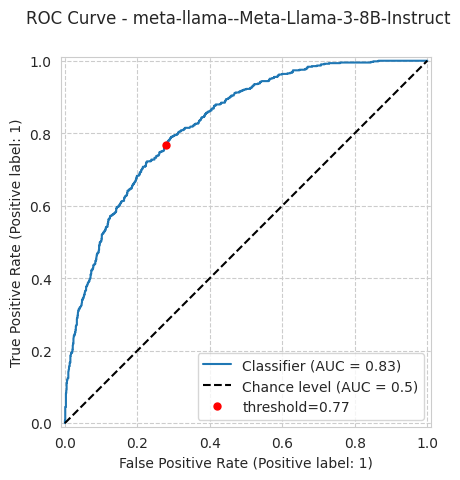

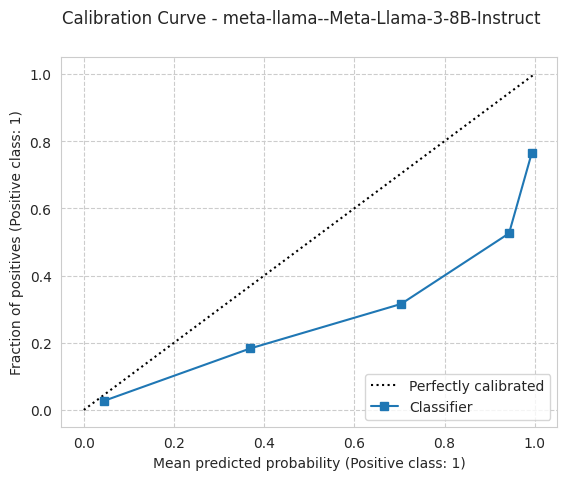

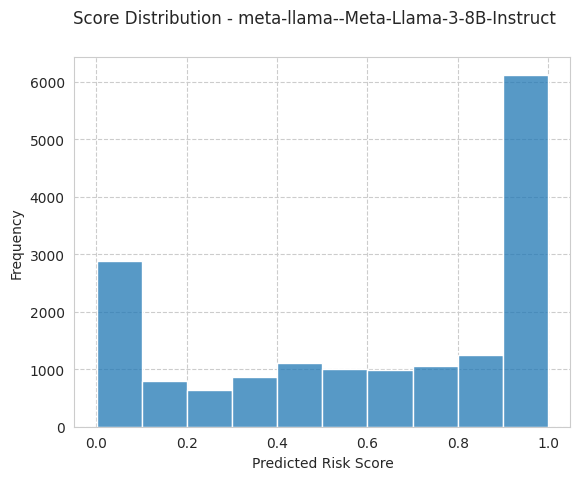

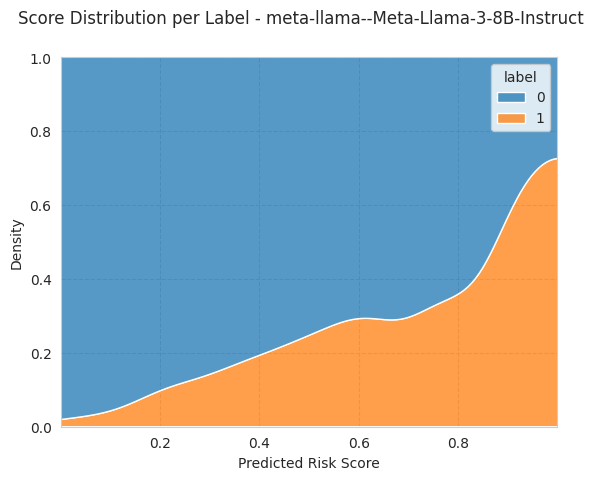

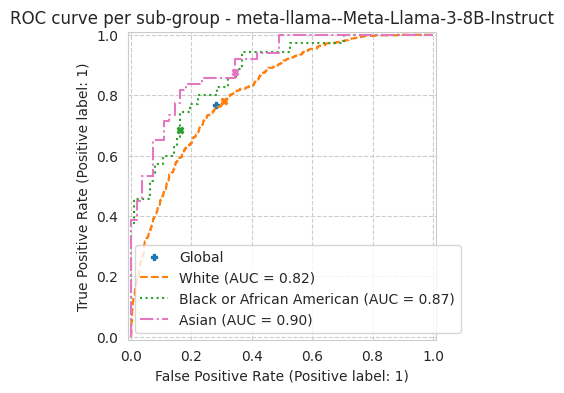

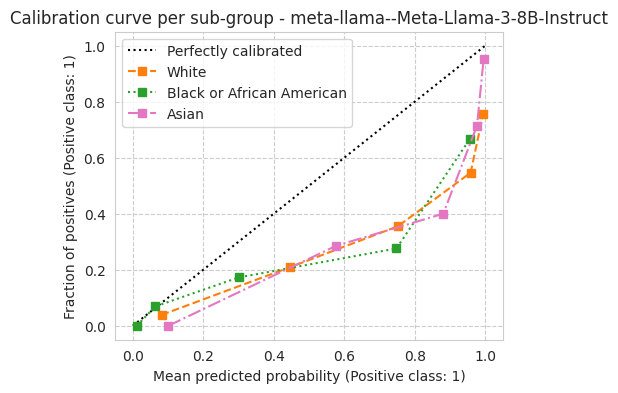

In [18]:
bench.plot_results();

In [19]:
from pprint import pprint
pprint(bench.results, depth=1)

{'accuracy': 0.7375375375375376,
 'accuracy_diff': 0.07650299098757829,
 'accuracy_ratio': 0.9046954264815762,
 'balanced_accuracy': 0.7442031810385155,
 'balanced_accuracy_diff': 0.0293317060366467,
 'balanced_accuracy_ratio': 0.961710366786746,
 'benchmark_hash': 1202604976,
 'brier_score_loss': 0.2461750243479347,
 'config': {...},
 'current_time': '2026.06.09-16.49.33',
 'ece': 0.24756101066355196,
 'ece_quantile': 0.24756101066355177,
 'equalized_odds_diff': 0.19183673469387752,
 'equalized_odds_ratio': 0.38961038961038963,
 'fnr': 0.23140495867768596,
 'fnr_diff': 0.19183673469387755,
 'fnr_ratio': 0.38961038961038963,
 'fpr': 0.280188679245283,
 'fpr_diff': 0.18474025974025973,
 'fpr_ratio': 0.4652255639097745,
 'log_loss': 0.8497331376381818,
 'model_name': 'meta-llama--Meta-Llama-3-8B-Instruct',
 'n_negatives': 1060,
 'n_positives': 605,
 'n_samples': 1665,
 'plots': {...},
 'ppr': 0.45765765765765765,
 'ppr_diff': 0.31043956043956045,
 'ppr_ratio': 0.4792626728110599,
 'preci

---